# **Assessment 8 - K-Means vs. DBSCAN: Choosing the Right Clustering Algorithm**

Adrian Ada

Hannah Fatima Garin

Bienn Mata

Eira Mae Benita Young

2DSA1

---

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

from sklearn.preprocessing import StandardScaler

---

### Part 1 — Data Preparation

In [6]:
df = pd.read_csv("CC GENERAL.csv")
features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']
df =  df[features]
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.\n")

def look_for_missing(dataset):
    """
    required dataset that prints out the names of columns that has missing values,
    does not do anything to the dataset but look only
    """
    if dataset.isna().any().sum() > 0 or dataset.isnull().any().sum() > 0 or (dataset == '?').any().sum() > 0:
        print("Missing Values found at\n")
        dataset = dataset.isna().any()
        dataset = dataset[dataset == True].index.tolist()
        print(f"{dataset}\n")
        return dataset
    else:
        print("No missing values are found.")

df_missing = look_for_missing(dataset=df)

print(f"Found missing {df[df_missing[0]].isna().sum()} values in {df_missing[0]}")
print(f"Found missing {df[df_missing[1]].isna().sum()} values in {df_missing[1]}")

print(f"Dropping values...\n")

df = df.dropna(subset=df_missing, inplace=False)

print(f"Dropped! "
      f"New Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset has 8950 rows and 6 columns.

Missing Values found at

['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']

Found missing 1 values in CREDIT_LIMIT
Found missing 313 values in MINIMUM_PAYMENTS
Dropping values...

Dropped! New Dataset has 8636 rows and 6 columns.


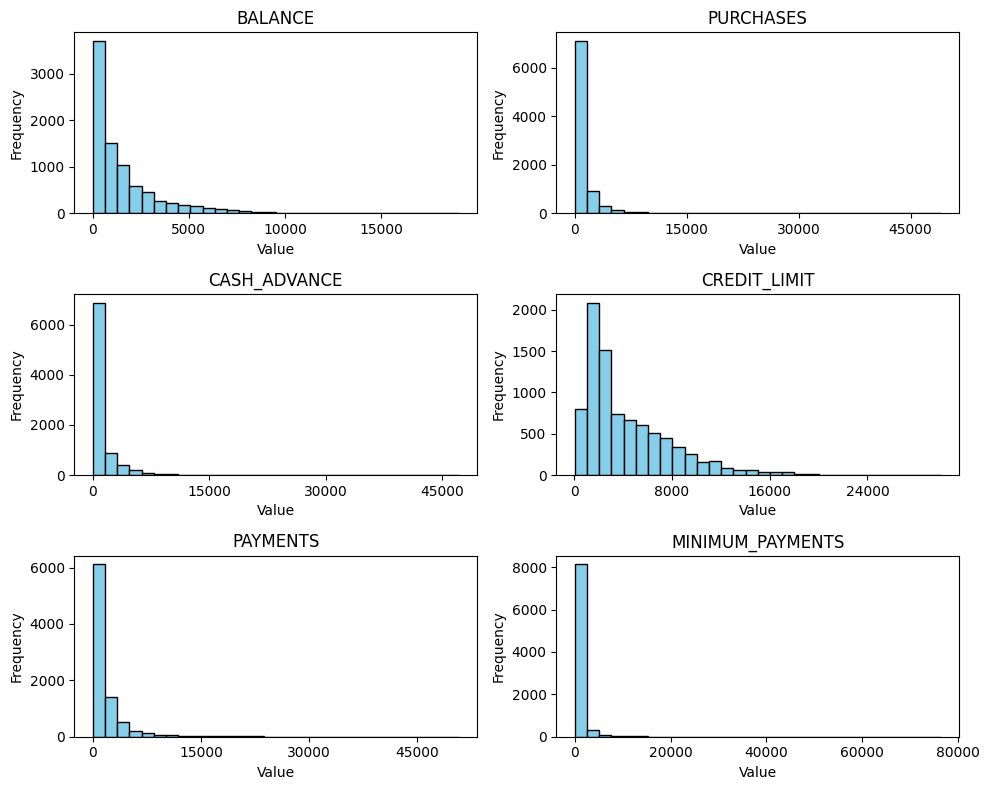

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8))

columns = df.columns.tolist()

for i, ax in enumerate(axs.flatten()):
    col = df[columns[i]]
    ax.hist(col, bins=30, color='skyblue', edgecolor='black')
    ax.set_title(columns[i])
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    # Zoom into the 1st–99th percentile range; uncomment to see the data zoomed in on the 99th percentile
    #ax.set_xlim(col.quantile(0.01), col.quantile(0.99))

plt.tight_layout()
plt.show()

From the graphs of the distribution of the features, all are right skewed where most of the data is concentrated on the left (Mean > Median > Mode, see cell below). There are potentially many outliers due to the large range of values relative to the shape of the distribution, where there could potentially be outliers on the right tail of the distribution of each feature. 

In [18]:
df.describe().transpose().round(4)

#50th percentile is the Median

,count,mean,std,min,25%,50%,75%,max
BALANCE,8636.0,1601.2249,2095.5713,0.0000,148.0952,916.8555,2105.1959,19043.1386
PURCHASES,8636.0,1025.4339,2167.1080,0.0000,43.3675,375.4050,1145.9800,49039.5700
CASH_ADVANCE,8636.0,994.1755,2121.4583,0.0000,0.0000,0.0000,1132.3855,47137.2118
CREDIT_LIMIT,8636.0,4522.0910,3659.2404,50.0000,1600.0000,3000.0000,6500.0000,30000.0000
PAYMENTS,8636.0,1784.4781,2909.8101,0.0495,418.5592,896.6757,1951.1421,50721.4834
MINIMUM_PAYMENTS,8636.0,864.3049,2372.5664,0.0192,169.1635,312.4523,825.4965,76406.2075


Text(0.5, 1.0, 'Correlation Matrix Heatmap')

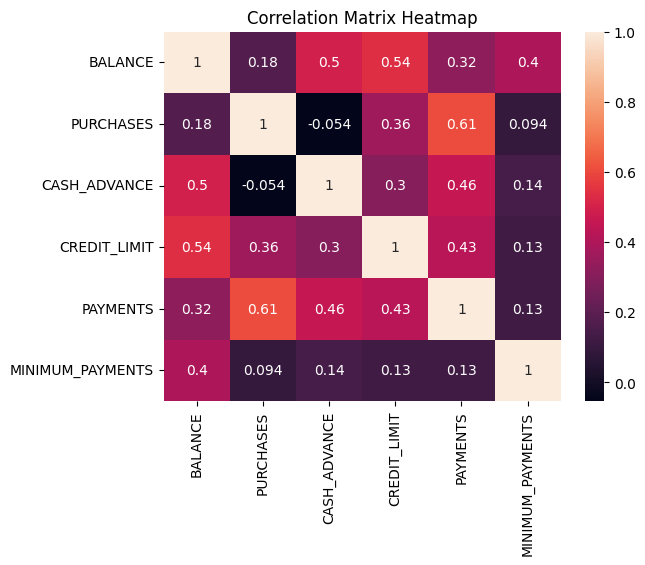

In [23]:
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix Heatmap")

There is an obvious relationship between balance and with all its features are all highly correlated since money is important in each of these features. Credit Limit is correlated highly with payments since higher payments lead to higher credit score leading to higher credit limit. Lastly and obvious relationship is purchases and payment correlation. Since to make more purchases leads to higher payment.

In [12]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

print("Shape of the data:", X.shape)

Shape of the data: (8636, 6)


### Part 2 — K-Means Clustering

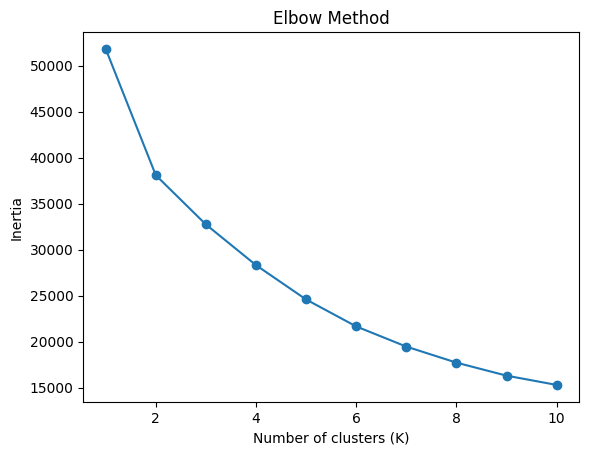

In [13]:
from sklearn.cluster import KMeans

K_range = range(1, 11)
inertia = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

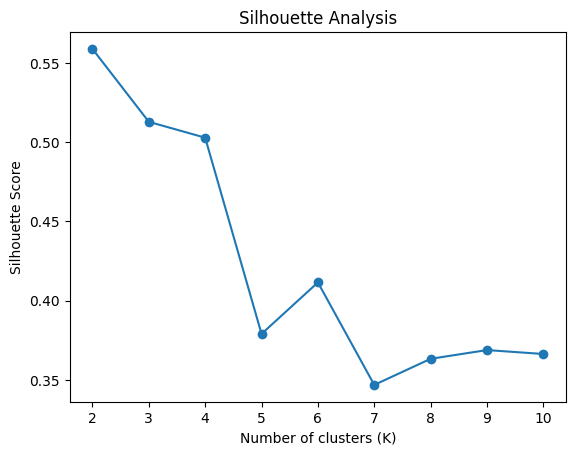

In [ ]:
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

Choosing **K=3** strikes the best balance between the two evaluation methods: the Elbow Method shows a clear inflection around three clusters, indicating that adding more clusters beyond this point yields diminishing returns in reducing inertia, while the Silhouette Analysis, though highest at K=2, still maintains a reasonably strong score at K=3 compared to larger values. This means that three clusters capture more structure in the data than just two, without fragmenting it into poorly separated groups as seen with higher K values. In practice, K=3 provides a compromise. Clusters that are compact and distinct enough to be meaningful, while also reflecting more nuanced patterns in the dataset than a binary split.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

chosen_k = 3

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# Evaluation metrics
sil_avg = silhouette_score(X, labels)
db_index = davies_bouldin_score(X, labels)
ch_index = calinski_harabasz_score(X, labels)

print(f"Silhouette Score: {sil_avg:.4f}")
print(f"Davies-Bouldin Index: {db_index:.4f}")
print(f"Calinski-Harabasz Index: {ch_index:.4f}")

Silhouette Score: 0.5129
Davies-Bouldin Index: 1.2825
Calinski-Harabasz Index: 2515.2800


The clustering model demonstrates a solid performance with a **Silhouette Score of 0.5129**, indicating that the three identified groups are well-defined and possess distinct characteristics. Furthermore, the high **Calinski-Harabasz Index of 2515.28** and a respectable **Davies-Bouldin Index of 1.2825** confirm that the clusters are both internally dense and effectively separated from one another.

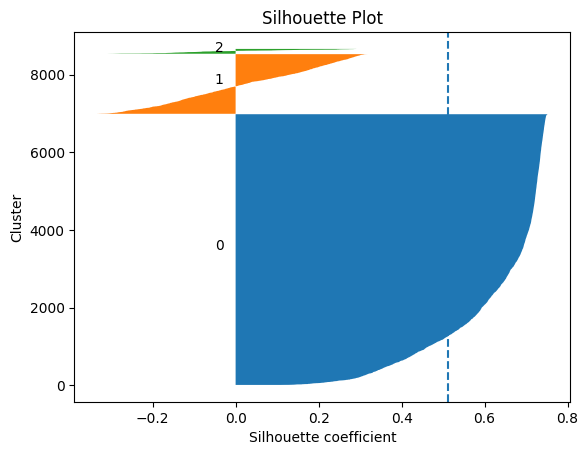

In [ ]:
from sklearn.metrics import silhouette_samples
import numpy as np
import matplotlib.pyplot as plt

sample_sil_values = silhouette_samples(X, labels)

plt.figure()
y_lower = 10

for i in range(chosen_k):
    ith_vals = sample_sil_values[labels == i]
    ith_vals.sort()

    size = ith_vals.shape[0]
    y_upper = y_lower + size

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals)
    plt.text(-0.05, y_lower + size/2, str(i))

    y_lower = y_upper + 10

plt.axvline(x=sil_avg, linestyle="--")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.title("Silhouette Plot")
plt.show()

This silhouette plot shows that all three clusters (blue, orange, green) have positive average silhouette coefficients, with the overall mean around 0.45, indicating moderately well-separated groups. The relatively consistent widths suggest the clusters are reasonably cohesive, though not perfectly distinct.

In [ ]:
# 1. Getting the centroids from the kmeans object
centroids_scaled = kmeans.cluster_centers_

# 2. Inversing transform to get original units
centroids_original = scaler.inverse_transform(centroids_scaled)

df_centroids = pd.DataFrame(
    centroids_original,
    columns=['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']
)

print("Cluster Centroids in Original Units:")
display(df_centroids)

Cluster Centroids in Original Units:


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
0,-0.356730,-0.120590,-0.256663,-0.304667,-0.216002,-0.161938
1,1.491148,0.165420,1.001129,1.203008,0.522295,0.679647
2,1.523143,4.687093,1.979676,2.169622,5.611352,0.657696


## Interpretation:
**Cluster 0** - Customers with below-average balances, purchases, cash advances, credit limits, payments, and minimum payments, indicating low overall credit card usage and engagement.

**Cluster 1** - Customers with high balances and credit limits, moderate cash advances and payments, but generally average purchasing behavior, suggesting active but controlled credit usage.

**Cluster 2** - Customers with very high purchases, payments, and credit limits, along with high balances and cash advances, indicating heavy and highly active credit card users.